In [5]:
using Turing
using Jens, CUDA
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots
using Jens:LensCosmo as LC
using Jens:LensPSF as LP

using Jens.LensModel.ComLens: CombinedLens
using Jens.LensModel: NFWE, Shear, SIS
using Jens.LightModel: CompositeImage, ExtendedSource, PointImage, PointImages
using Jens.LightModel.SersicLight: SersicSpheric
using Jens.LensSystem: ForwardModel, render

In [3]:
# Cosmology + grid + PSF 
cosmo = LC.Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
z_lens, z_src = 0.3, 1.5

grid_cpu = LG.GenGrid(pix_n=128, pix_size=0.08)              # CPU
grid_gpu = gpu_grid(pix_n=128, pix_size=Float32(0.08))  # GPU

psf = LP.GaussianPSF(; fwhm=0.12)

Jens.LensPSF.GaussianPSF{Float64}(0.12)

In [6]:
# Lens model
lens = CombinedLens(
    NFWE   => (Rs=5.0, alpha_Rs=1.0, e1=0.2, e2=0.1, xcentre=0.0, ycentre=0.0),
    Shear => (gamma1=0.05, gamma2=-0.03, xcentre=0.0, ycentre=0.0))

# Light model
# host
host = ExtendedSource(SersicSpheric;
    amp=1.0, Rsersic=0.3, n=2.0, xcentre=0.0, ycentre=0.0)

# point source
agn_images = [
    ( 0.206, -0.232),   # image A
    (-0.415,  0.311),   # image B
]
agn = PointImages((2.0, agn_images); intrinsic=true)

# combine
src = CompositeImage(host, agn)

CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImages{Float64}}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 1.0, Rsersic = 0.3, n = 2.0, xcentre = 0.0, ycentre = 0.0)), PointImages{Float64}([(2.0, [(0.206, -0.232), (-0.415, 0.311)])], true)))

In [10]:
sys = ForwardModel(
    lens_plane   = LG.LensedPlane(lens; z_lens, cosmology=cosmo),
    source_plane = LG.LightPlane(src; z=z_src),
    grid = grid_gpu, psf = psf,
)

@time img = render(sys);

  0.000973 seconds (3.41 k allocations: 486.695 KiB)


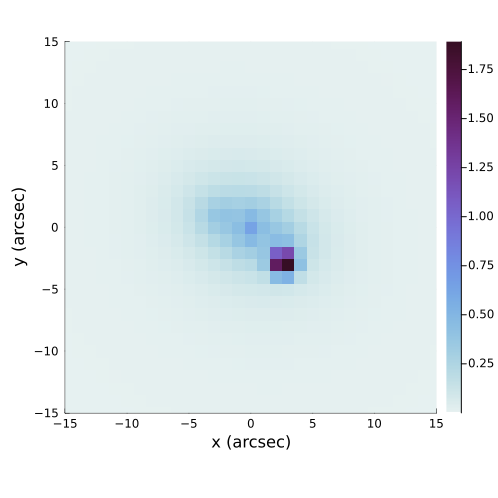

In [35]:
canvas = Jplots.LensCanvas(;  xlims=(-15,15), ylims=(-15,15),
        size=(500,500))
Jplots.PlotPlane!(canvas, Array(img) )
display(canvas)

In [5]:
# SIM real img
data  = Float64.(Array(img))   

sigma = max(median(abs.(data)) * 0.1, 1e-3)           # noise

data_noisy = data .+ sigma .* randn(size(data));

In [6]:
# likelihood
function logp_fn(p::Vector{Float64})
    theta_E, amp, Rsersic = p

    # 从参数重建模型
    m  = CombinedLens(#SIS => (theta_E=theta_E, xcentre=0.0, ycentre=0.0),
                NFWE   => (Rs=theta_E, alpha_Rs=1.0, e1=0.2, e2=0.1, xcentre=0.0, ycentre=0.0),
                Shear => (gamma1=0.05, gamma2=-0.03, xcentre=0.0, ycentre=0.0)
                      )
    lp = LG.LensedPlane(m; z_lens, cosmology=cosmo)
    h  = ExtendedSource(SersicSpheric;
        amp=amp, Rsersic=Rsersic, n=2.0, xcentre=0.0, ycentre=0.0)
    a  = PointImage(flux=50.0, beta_x=0.05, beta_y=-0.03)  # 可固定或加入参数

    sys = ForwardModel(
        lens_plane   = lp,
        source_plane = LG.LightPlane(CompositeImage(h,a); z=z_src),
        grid = grid_gpu, psf = psf)

    img = render(sys)
    return -sum((data_noisy .- Float64.(Array(img))).^2) / (2*sigma^2)
end

logp_fn (generic function with 1 method)

In [15]:
0.03*24

0.72

In [ ]:
using Jens.LensHMC

lower = [0.2, 0.1, 0.05]    # prior bounds 
upper = [10.0, 5.0, 1.0]
init  = [5.5, 0.9, 0.35]


range_all = upper .- lower
step0 = range_all ./ 5

result = lens_hmc(logp_fn, lower, upper;
    n = 100, init = init, seed = 42)

# n_chains for multi-thread
#chains = lens_mh_multi(logp_fn, lower, upper; step0 = step0,
#    n_chains=4, n=1000, adapt=false)

[ Info: Found initial step size 1.81254486389386e-9


In [16]:
# summary
summary = chain(result; burn=100)          # (n_params, n_samples) 
means, stds = chain_stats(result; burn=100)

([5.489155665472542, 1.1639786673582069, 0.3258423232576049], [0.0025969158700840716, 0.009512804528354454, 0.0016508800024409426])

In [17]:
using StatsPlots,PairPlots, MCMCChains, CairoMakie

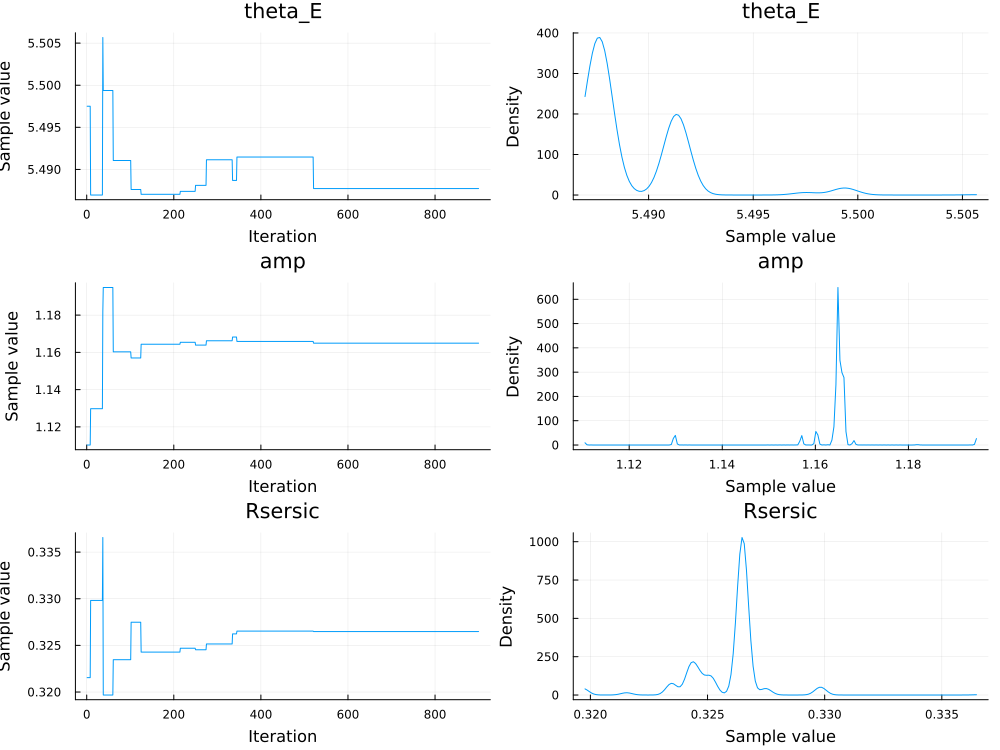

In [18]:
chn = Chains(summary', [:theta_E, :amp, :Rsersic])
ChainPlot = StatsPlots.plot(chn)

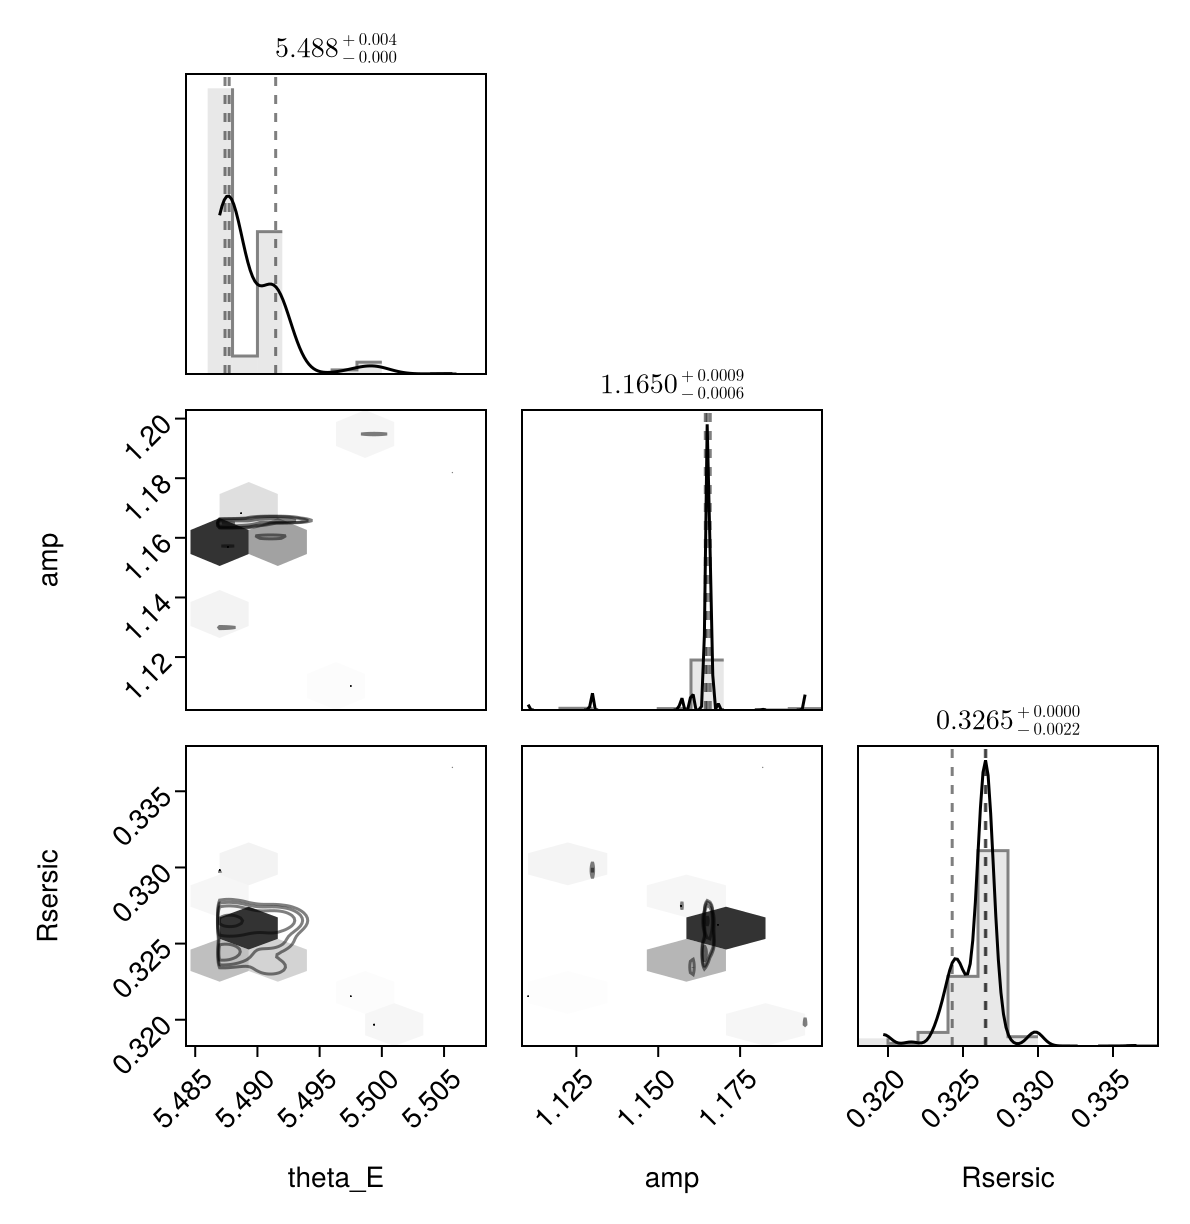

In [19]:
corner_fig = PairPlots.pairplot(chn)


|  MCMC （500 strps MH，3-para SIS）                     |   
|  grid   |   CPU    |    GPU   |   加速比  |    ms/step(CPU) | ms/step(GPU)|
|------|------|------|------|------|------|
|   64²  |    0.5 s   |   1.7 s  |  0.3  |    1.0    |     3.4|
|  128²   |   0.8 s  |    0.3 s  |  2.7    |     1.7   |      0.6|
|  256²   |   6.9 s   |   0.4 s  | 19.1   |  13.9    |     0.7|